# 10 · Non-motor phenotypes via PCA + KMeans

Method from PIGD compendium (Technique 4): scale → PCA (retain 85% variance) → KMeans with K∈{2..5} chosen by Silhouette + Calinski-Harabasz + Davies-Bouldin. Then look at how pain trajectories differ across non-motor phenotypes. Bootstrap ARI for stability.

In [1]:
source("helpers/pain_helpers.R")
suppressPackageStartupMessages({
  library(dplyr); library(tidyr); library(ggplot2); library(cluster); library(factoextra)
})

df <- readRDS(file.path(OUT_OBJ, "pain_long.rds"))
base <- df %>% dplyr::arrange(PATNO, INFODT_orig) %>%
  dplyr::group_by(PATNO) %>% dplyr::slice_head(n = 1) %>% dplyr::ungroup()

cluster_vars <- c(
  "NP1PAIN","NP1SLPN","NP1SLPD","NP1FATG","NP1URIN",
  "NP1DPRS","NP1ANXS",
  "gds","stai","ess","rem","scopa","updrs3_score","BMI"
)
X0 <- base %>% dplyr::select(PATNO, will_receive_dbs, dplyr::all_of(cluster_vars)) %>%
  tidyr::drop_na()
cat("Complete-case patients for clustering:", nrow(X0), "\n")
print(dplyr::count(X0, will_receive_dbs))

X <- X0 %>% dplyr::select(dplyr::all_of(cluster_vars)) %>% as.matrix()
# Winsorise to p2–p98
X <- apply(X, 2, function(col) {
  q <- stats::quantile(col, c(0.02, 0.98), na.rm = TRUE)
  pmin(pmax(col, q[1]), q[2])
})
Xs <- scale(X)

Complete-case patients for clustering: 104 


# A tibble: 2 × 2
  will_receive_dbs     n
  <lgl>            <int>
1 FALSE               69
2 TRUE                35


In [2]:
# PCA retaining 85% variance
pca <- stats::prcomp(Xs, center = FALSE, scale. = FALSE)
vx <- pca$sdev^2 / sum(pca$sdev^2)
cum <- cumsum(vx)
n_pc <- which(cum >= 0.85)[1]
cat("PCs retained for 85% variance:", n_pc, "\n")
Z <- pca$x[, seq_len(n_pc), drop = FALSE]

# Evaluate K=2..5
eval_k <- function(K) {
  set.seed(42)
  km <- stats::kmeans(Z, centers = K, nstart = 50, iter.max = 1000)
  sil <- cluster::silhouette(km$cluster, dist(Z))
  tibble::tibble(K = K, sil = mean(sil[, 3]), withinss = km$tot.withinss,
                 size_min = min(km$size), size_max = max(km$size))
}
res <- purrr::map_dfr(2:5, eval_k)
print(res)
save_table(res, "kmeans_K_selection")

PCs retained for 85% variance: 9 


# A tibble: 4 × 5
      K   sil withinss size_min size_max
  <int> <dbl>    <dbl>    <int>    <int>
1     2 0.278     978.       25       79
2     3 0.160     865.       13       55
3     4 0.158     792.        7       44
4     5 0.152     732.        9       44


In [3]:
best_K <- res %>% dplyr::filter(size_min >= 0.03 * nrow(Z)) %>%
  dplyr::slice_max(sil, n = 1) %>% dplyr::pull(K)
cat("Best K:", best_K, "\n")
set.seed(42)
km <- stats::kmeans(Z, centers = best_K, nstart = 100, iter.max = 2000)
X0$cluster <- km$cluster

# Cluster characterisation — medians per variable
cluster_profile <- X0 %>% dplyr::select(cluster, dplyr::all_of(cluster_vars)) %>%
  dplyr::group_by(cluster) %>%
  dplyr::summarise(dplyr::across(dplyr::everything(), ~ stats::median(.x, na.rm = TRUE)),
                   n = dplyr::n(), .groups = "drop") %>%
  dplyr::relocate(cluster, n)
print(cluster_profile)
save_table(cluster_profile, "kmeans_cluster_profile")

# Cluster × DBS
ctab <- table(X0$cluster, dplyr::if_else(X0$will_receive_dbs, "DBS", "Never-DBS"))
print(ctab); print(prop.table(ctab, margin = 2))
print(suppressWarnings(stats::chisq.test(ctab)))

Best K: 2 


# A tibble: 2 × 16
  cluster     n NP1PAIN NP1SLPN NP1SLPD NP1FATG NP1URIN NP1DPRS NP1ANXS   gds
    <int> <int>   <dbl>   <dbl>   <dbl>   <dbl>   <dbl>   <dbl>   <dbl> <dbl>
1       1    79       1       1       1       1       1       0       0     1
2       2    25       2       2       1       1       1       0       1     4
# ℹ 6 more variables: stai <dbl>, ess <dbl>, rem <dbl>, scopa <dbl>,
#   updrs3_score <dbl>, BMI <dbl>


   
    DBS Never-DBS
  1  26        53
  2   9        16


   
          DBS Never-DBS
  1 0.7428571 0.7681159
  2 0.2571429 0.2318841



	Pearson's Chi-squared test with Yates' continuity correction

data:  ctab
X-squared = 0.0017662, df = 1, p-value = 0.9665



In [4]:
# Pain trajectory by cluster — per-patient pre/post Δ
delta <- readRDS(file.path(OUT_OBJ, "pain_delta_responder.rds")) %>%
  dplyr::select(PATNO, delta, will_receive_dbs)
dat <- X0 %>% dplyr::select(PATNO, cluster) %>%
  dplyr::inner_join(delta, by = "PATNO")
cat("Patients with cluster + Δpain:", nrow(dat), "\n")
print(dat %>% dplyr::group_by(cluster) %>%
  dplyr::summarise(n = dplyr::n(), mean_d = mean(delta),
                   pct_worsen = mean(delta >= 1), .groups = "drop"))

if (nrow(dat) > 0 && dplyr::n_distinct(dat$cluster) > 1) {
  kw <- stats::kruskal.test(delta ~ factor(cluster), data = dat)
  print(kw)
}

Patients with cluster + Δpain: 38 


# A tibble: 2 × 4
  cluster     n mean_d pct_worsen
    <int> <int>  <dbl>      <dbl>
1       1    27  0.367      0.259
2       2    11 -0.346      0.182



	Kruskal-Wallis rank sum test

data:  delta by factor(cluster)
Kruskal-Wallis chi-squared = 2.7653, df = 1, p-value = 0.09633



In [5]:
# Bootstrap ARI stability for the KMeans solution
set.seed(42)
ari <- function(a, b) {
  # Adjusted Rand Index via mclust fallback
  if (!requireNamespace("mclust", quietly = TRUE)) return(NA_real_)
  mclust::adjustedRandIndex(a, b)
}
B <- 100
orig <- km$cluster
aris <- numeric(B)
for (b in seq_len(B)) {
  idx <- sample.int(nrow(Z), replace = TRUE)
  set.seed(1000 + b)
  km_b <- stats::kmeans(Z[idx, , drop = FALSE], centers = best_K, nstart = 10, iter.max = 500)
  # Align bootstrap labels back to original via majority vote
  aris[b] <- ari(orig[idx], km_b$cluster)
}
cat(sprintf("Bootstrap ARI — mean: %.3f  95%% CI: [%.3f, %.3f]\n",
            mean(aris, na.rm = TRUE),
            stats::quantile(aris, 0.025, na.rm = TRUE),
            stats::quantile(aris, 0.975, na.rm = TRUE)))
save_object(list(aris = aris, K = best_K), "kmeans_bootstrap")

Bootstrap ARI — mean: 0.783  95% CI: [0.322, 1.000]


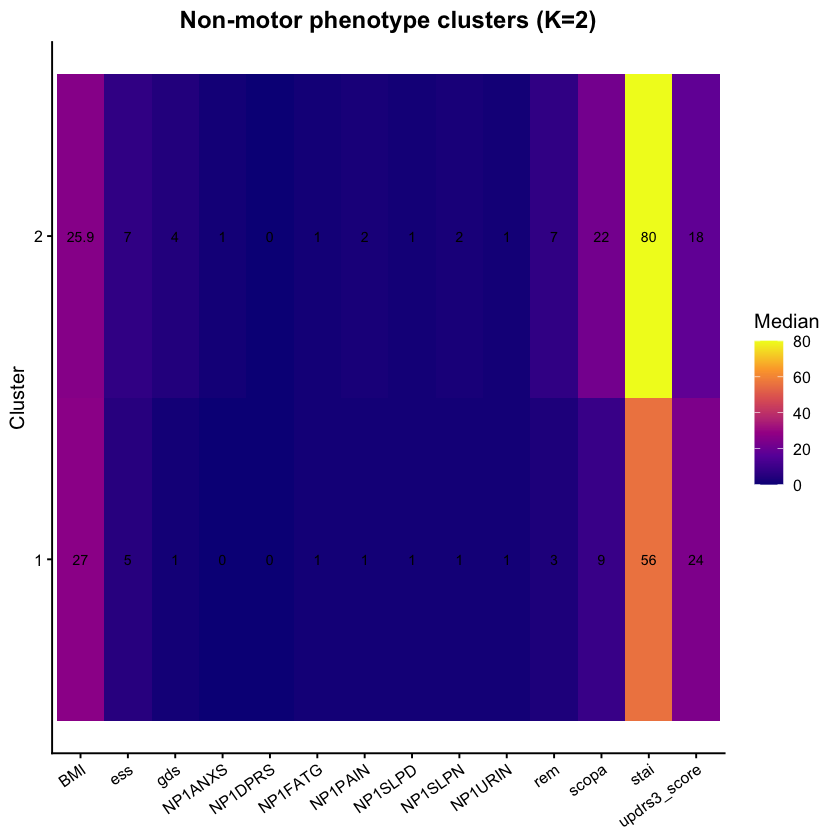

In [6]:
# Radar-like heatmap of cluster profiles
prof_long <- cluster_profile %>% dplyr::select(-n) %>%
  tidyr::pivot_longer(-cluster, names_to = "variable", values_to = "median")
p_hm <- ggplot(prof_long, aes(x = variable, y = factor(cluster), fill = median)) +
  geom_tile() +
  geom_text(aes(label = round(median, 1)), size = 3) +
  scale_fill_viridis_c(option = "C") +
  labs(title = sprintf("Non-motor phenotype clusters (K=%d)", best_K),
       x = NULL, y = "Cluster", fill = "Median") +
  theme_classic(base_size = 12) +
  theme(plot.title = element_text(face = "bold", hjust = 0.5),
        axis.text.x = element_text(angle = 35, hjust = 1))
p_hm
save_fig(p_hm, "Fig19_nm_cluster_heatmap", width = 8.5, height = 4.5)
save_object(X0, "nm_cluster_membership")